In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from semantic_state_estimator.semantic_state_estimator import *

In [ ]:
 pddl2nl = PDDL2NLQueryConverter.from_uninitialized(
    'OpenAI/gpt-4o-2024-11-20', 'examples/gw_grip_home/domain.pddl', 'examples/gw_grip_home/problem.pddl'
)

In [ ]:
pddl2nl.convert_to_nl(['on-table(milk-carton,wood-table)'])

In [ ]:
pbar = tqdm(pddl2nl.all_grounded_predicates)
queries = {}
for predicate in pbar:
    pbar.set_description(f"converting predicate: {predicate}")
    queries[predicate] = pddl2nl.convert_to_nl(predicate)

In [ ]:
from PIL import Image
import requests
from io import BytesIO

response = requests.get("https://media.roboflow.com/notebooks/examples/dog.jpeg")
img = Image.open(BytesIO(response.content))

In [ ]:
img

In [ ]:
from semantic_state_estimator.utils.open_ai_utils import estimation_query

In [ ]:
resp = estimation_query(
    model_id="gpt-4o-2024-11-20",
    images=[img],
    query="is the dog wearing a leash",
    system="you are to answer yes or no questions like a pirate"
)

In [ ]:
''.join(map(lambda x: x.token, resp.choices[0].logprobs.content))

In [ ]:
top_logprobs = resp.choices[0].logprobs.content[0].top_logprobs

In [ ]:
token_groups = [['Y', 'A', 'x'], ['3', 'Yo', '7']]

In [ ]:
from collections import defaultdict

In [ ]:
import numpy as np
tok_to_prob = defaultdict(int)
for item in top_logprobs:
    tok_to_prob[item.token] = np.exp(item.logprob)

In [ ]:
tok_to_prob

In [ ]:
token_groups_probs = [
            np.sum([tok_to_prob[token]for token in token_group])
            for token_group in token_groups
        ]

In [ ]:
np.sum(token_groups_probs)

In [ ]:
g1, g2 = [prob / np.sum(token_groups_probs, axis=0) for prob in token_groups_probs]

In [ ]:
np.sum([g1, g2])

# Test system prompts

## GW

In [26]:
from PIL import Image
from semantic_state_estimator.semantic_state_estimator import *
from semantic_state_estimator.constants import GPT_41_LATEST

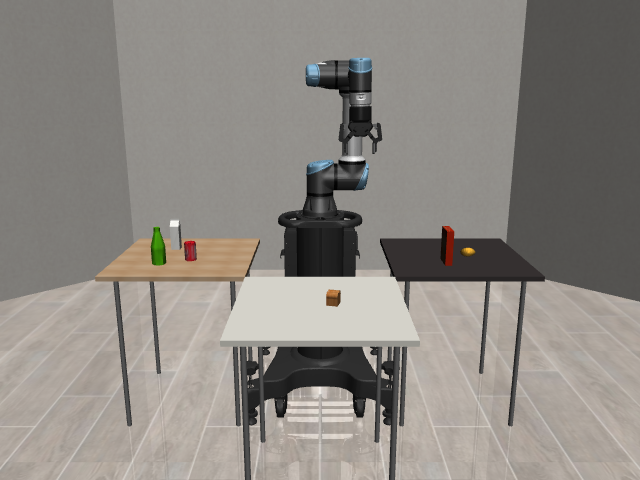

In [28]:
import glob
img_paths = glob.glob('dp5_imgs/*.png')

imgs = []
for pth in img_paths:
    imgs.append(Image.open(pth))
imgs[0]

In [27]:
se = SemanticStateEstimator('examples/gw_grip/domain.pddl', 'examples/gw_grip/problem.pddl', GPT_41_LATEST, GPT_41_LATEST)
se.vqa_model.system_prompt

predicate queries loaded from cache


"A curious human is asking an artificial intelligence assistant yes or no questions. The assistant answers with one of two responses: YES or NO. The assistant's response should not include any additional text."

In [29]:
state = se.estimate_state_par(imgs, 1)
state

  0%|          | 0/25 [00:00<?, ?it/s]

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1 in organization org-myNn8GnBmAYzBjVMrBygdeq8 on tokens per min (TPM): Limit 30000, Used 27129, Requested 4657. Please try again in 3.572s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

In [16]:
add = """The user will show you images of a simulated robot and ask questions about the state of the environment.
The milk carton is a clean white rectangular box with a triangular top.
When the robot is holding the milk carton it looks like there is a white rectangular object being pinched by the robot's gripper."""

se = SemanticStateEstimator('examples/gw_grip/domain.pddl', 'examples/gw_grip/problem.pddl', 'OpenAI/gpt-4o-2024-11-20', 'OpenAI/gpt-4o-2024-11-20',
                            additional_instructions=add)
print(se.vqa_model.system_prompt)

predicate queries loaded from cache
A curious human is asking an artificial intelligence assistant yes or no questions. The assistant answers with one of two responses: YES or NO. The assistant's response should not include any additional text.
Additional Instructions and clarifications:
The user will show you images of a simulated robot and ask questions about the state of the environment.
The milk carton is a clean white rectangular box with a triangular top.
When the robot is holding the milk carton it looks like there is a white rectangular object being pinched by the robot's gripper.


In [17]:
state = se.estimate_state_par(imgs, 1)
state

  0%|          | 0/25 [00:00<?, ?it/s]

{'on-table(milk-carton,wood-table)': 0.9525741323893877,
 'on-table(milk-carton,black-table)': 4.599055367023639e-10,
 'on-table(milk-carton,white-table)': 2.902316695115694e-06,
 'on-table(lemon,wood-table)': 1.4449803160788765e-07,
 'on-table(lemon,black-table)': 0.9999999006880528,
 'on-table(lemon,white-table)': 9.056076943949647e-11,
 'on-table(green-bottle,wood-table)': 0.9999999634651813,
 'on-table(green-bottle,black-table)': 2.7894680836865653e-10,
 'on-table(green-bottle,white-table)': 9.056076923604168e-11,
 'on-table(loaf-of-bread,wood-table)': 7.582560384474052e-10,
 'on-table(loaf-of-bread,black-table)': 3.5817479030359803e-10,
 'on-table(loaf-of-bread,white-table)': 0.9999999981810381,
 'on-table(red-box-of-cereal,wood-table)': 3.0590235869206005e-07,
 'on-table(red-box-of-cereal,black-table)': 0.9999977396744818,
 'on-table(red-box-of-cereal,white-table)': 2.0611536079454527e-09,
 'on-table(red-can-of-soda,wood-table)': 0.9999977396745358,
 'on-table(red-can-of-soda,bla

## PRB

In [ ]:
from PIL import Image
from semantic_state_estimator.semantic_state_estimator import *
from semantic_state_estimator.constants import GPT_41_LATEST

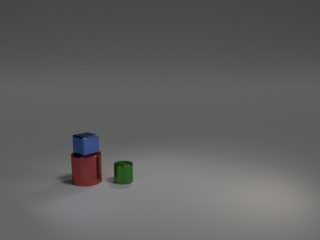

In [25]:
import glob
img_paths = glob.glob('dpPRB_imgs/*.png')

imgs = []
for pth in img_paths:
    imgs.append(Image.open(pth))
imgs[0]

In [ ]:
se = SemanticStateEstimator('examples/prb/domain.pddl', 'examples/prb/problem.pddl', 'OpenAI/gpt-4o-2024-11-20', 'OpenAI/gpt-4o-2024-11-20')
se.vqa_model.system_prompt